# Q3 — Propagation of generator differences into parsimonious reconciliation

This notebook reads existing Capybara results only. It never reruns Capybara and never uses generating-history frequencies or recovery-distance columns. Comparisons are made within the same intended regime and cost vector across AsymmeTree, Coala, Cophylo, and TreeDucken.

Completed AsymmeTree results from the 300-second retry workbook replace matching main-workbook tasks by dataset path and cost label. Unsuccessful retries do not replace main results. Source workbooks and the merge audit are recorded in the output tables.


In [ ]:
import sys
from pathlib import Path

# Locate the repository root so the notebook runs from any working directory
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "synthetic_datasets.py").exists())
sys.path.insert(0, str(REPO_ROOT))
from decimal import Decimal, localcontext
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

INPUT_FILE = REPO_ROOT / "synthetic_data_capybara_results.xlsx"
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Missing Capybara results: {INPUT_FILE.relative_to(REPO_ROOT)}")

# Set to None only to explicitly analyze the main workbook without retries.
RETRY_INPUT = REPO_ROOT / "synthetic_data_capybara_results_retry_asymmetree_300s.xlsx"

FIGURE_DIR = Path("downstream_figures")
TABLE_DIR = Path("downstream_tables")
FIGURE_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

GENERATORS = ["coala", "treeducken", "asymmetree", "cophylo"]
REGIONS = ["R1", "R2", "R3"]
COSTS = ["classical_1", "classical_3"]
COST_NAMES = {"classical_1": "<0,1,2,1>", "classical_3": "<0,1,3,1>"}
REGIME_TO_REGION = {"high_cosp": "R1", "low_switch": "R1", "high_switch": "R2", "medium": "R3"}
VALID_PAIRINGS = {
    ("coala", "high_cosp"), ("treeducken", "high_cosp"), ("asymmetree", "low_switch"),
    ("coala", "high_switch"), ("treeducken", "high_switch"), ("asymmetree", "high_switch"),
    ("coala", "medium"), ("treeducken", "medium"), ("asymmetree", "medium"),
    ("cophylo", "high_cosp"), ("cophylo", "high_switch"), ("cophylo", "medium"),
}
GENERATOR_COLORS = {"asymmetree": "#0072B2", "coala": "#E69F00", "treeducken": "#CC79A7", "cophylo": "#009E73"}
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Reading existing results from:", INPUT_FILE.relative_to(REPO_ROOT))

Reading existing results from: synthetic_data_capybara_results.xlsx


## Load completed classical-cost results

In [10]:
TASK_KEYS = ["dataset_path", "cost_label"]

def load_result_workbook(path):
    frames = []
    with pd.ExcelFile(path) as book:
        for sheet in book.sheet_names:
            frame = pd.read_excel(book, sheet_name=sheet)
            if {"dataset_path", "generator", "regime", "cost_label"}.issubset(frame.columns):
                frame["source_sheet"] = sheet
                frame["source_workbook"] = str(path)
                frames.append(frame)
    if not frames:
        raise ValueError(f"No result sheets found in {path}")
    frame = pd.concat(frames, ignore_index=True)
    for column in ["generator", "regime", "cost_label", "capybara_status"]:
        frame[column] = frame[column].fillna("").astype(str).str.strip().str.lower()
    frame["dataset_path"] = frame["dataset_path"].astype(str).map(lambda value: Path(value).as_posix())
    if frame.duplicated(TASK_KEYS).any():
        raise ValueError(f"Duplicate dataset/cost tasks in {path}")
    return frame


def merge_completed_retries(main, retry):
    if not retry["generator"].eq("asymmetree").all():
        raise ValueError("The AsymmeTree retry workbook contains other generators")
    main_keys = pd.MultiIndex.from_frame(main[TASK_KEYS])
    retry_keys = pd.MultiIndex.from_frame(retry[TASK_KEYS])
    if not retry_keys.isin(main_keys).all():
        raise ValueError("Retry tasks absent from the main workbook; check that the input files belong to the same run")
    original = main.set_index(TASK_KEYS).loc[retry_keys].reset_index()
    for column in ["generator", "regime", "cost_vector"]:
        if not original[column].astype(str).reset_index(drop=True).equals(retry[column].astype(str).reset_index(drop=True)):
            raise ValueError(f"Main/retry mismatch in {column}")
    successful = retry[retry["capybara_status"].eq("completed")].copy()
    successful_keys = pd.MultiIndex.from_frame(successful[TASK_KEYS])
    combined = pd.concat([main.loc[~main_keys.isin(successful_keys)], successful], ignore_index=True)
    if combined.duplicated(TASK_KEYS).any() or len(combined) != len(main):
        raise AssertionError("Retry merge changed task uniqueness or total task count")
    audit = retry[TASK_KEYS + ["generator", "regime", "source_workbook", "capybara_status"]].copy()
    audit = audit.rename(columns={"capybara_status": "retry_status"})
    audit["main_status"] = original["capybara_status"].to_numpy()
    audit["used_retry"] = audit["retry_status"].eq("completed")
    return combined, audit


main_results = load_result_workbook(INPUT_FILE)
results = main_results.copy()
retry_merge_audit = pd.DataFrame(columns=TASK_KEYS + ["generator", "regime", "source_workbook", "retry_status", "main_status", "used_retry"])
if RETRY_INPUT is not None:
    retry_results = load_result_workbook(RETRY_INPUT)
    results, retry_merge_audit = merge_completed_retries(main_results, retry_results)
    print(f"Retry tasks loaded: {len(retry_results):,}; completed retries used: {int(retry_merge_audit['used_retry'].sum()):,}")
    display(retry_merge_audit.groupby(["regime", "cost_label", "used_retry"]).size().rename("tasks").to_frame())
retry_merge_audit.to_csv(TABLE_DIR / "retry_merge_audit.csv", index=False)
results["region"] = results["regime"].map(REGIME_TO_REGION)
results["capybara_status"] = results["capybara_status"].fillna("").astype(str).str.lower()
pair_is_valid = pd.Series(list(zip(results["generator"], results["regime"])), index=results.index).isin(VALID_PAIRINGS)
completed = results[
    results["generator"].isin(GENERATORS)
    & results["cost_label"].isin(COSTS)
    & results["capybara_status"].eq("completed")
    & pair_is_valid
].copy()
completed["event_vector_count"] = pd.to_numeric(completed["event_vector_count"], errors="raise").astype(int)
if (completed["event_vector_count"] <= 0).any():
    raise ValueError("Completed rows with zero event_vector_count were found")

sample_sizes_completed = completed.groupby(["region", "generator", "cost_label"], as_index=False).agg(completed_datasets=("dataset_path", "nunique"))
sample_sizes_completed["cost_vector"] = sample_sizes_completed["cost_label"].map(COST_NAMES)
print("Completed datasets by region x generator x cost vector:")
display(sample_sizes_completed.sort_values(["region", "cost_label", "generator"]))

Retry tasks loaded: 768; completed retries used: 481


tasks
regime      cost_label  used_retry       
high_switch classical_1 False         202
                        True          245
            classical_3 False          84
                        True          188
            transformed True           44
medium      classical_1 True            3
            classical_3 True            1
            transformed False           1

Completed datasets by region x generator x cost vector:


,region,generator,cost_label,completed_datasets,cost_vector
0,R1,asymmetree,classical_1,1000,"<0,1,2,1>"
2,R1,coala,classical_1,1000,"<0,1,2,1>"
4,R1,cophylo,classical_1,989,"<0,1,2,1>"
6,R1,treeducken,classical_1,989,"<0,1,2,1>"
1,R1,asymmetree,classical_3,1000,"<0,1,3,1>"
3,R1,coala,classical_3,1000,"<0,1,3,1>"
5,R1,cophylo,classical_3,989,"<0,1,3,1>"
7,R1,treeducken,classical_3,990,"<0,1,3,1>"
8,R2,asymmetree,classical_1,798,"<0,1,2,1>"
10,R2,coala,classical_1,1000,"<0,1,2,1>"


## Parse distinct optimal event vectors and run required checks

In [11]:
EVENT_RX = re.compile(r"\[\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\]\s*of\s*size\s*(\d+)", re.I)
long_rows, parsing_failures = [], []
for row in completed.itertuples(index=False):
    matches = EVENT_RX.findall(str(row.event_vectors))
    if len(matches) != row.event_vector_count:
        parsing_failures.append({
            "dataset_path": row.dataset_path, "generator": row.generator, "regime": row.regime,
            "region": row.region, "cost_label": row.cost_label,
            "expected_event_vector_count": row.event_vector_count, "parsed_event_vector_count": len(matches),
        })
        continue
    for c, d, s, loss, multiplicity in matches:
        C, D, S, L, multiplicity = map(int, (c, d, s, loss, multiplicity))
        denominator = C + D + S + L
        if denominator <= 0:
            parsing_failures.append({"dataset_path": row.dataset_path, "generator": row.generator, "regime": row.regime, "region": row.region, "cost_label": row.cost_label, "expected_event_vector_count": row.event_vector_count, "parsed_event_vector_count": len(matches), "reason": "C+D+S+L <= 0"})
            break
        long_rows.append({
            "dataset_path": row.dataset_path, "generator": row.generator, "regime": row.regime,
            "region": row.region, "cost_label": row.cost_label,
            "source_workbook": row.source_workbook, "source_sheet": row.source_sheet,
            "C": C, "D": D, "S": S, "L": L, "multiplicity": multiplicity,
            "c_opt": C / denominator, "s_opt": S / denominator,
            "event_vector_count": row.event_vector_count,
        })

parsing_failures = pd.DataFrame(parsing_failures).drop_duplicates(["dataset_path", "cost_label"])
if not parsing_failures.empty:
    print("WARNING: profile parsing failed for these completed dataset/cost rows; they are excluded from profile analyses but retained in ambiguity analyses:")
    for path, cost, expected, parsed in parsing_failures[["dataset_path", "cost_label", "expected_event_vector_count", "parsed_event_vector_count"]].itertuples(index=False):
        print(f"  {path} | {cost} | expected {expected}, parsed {parsed}")
    parsing_failures.to_csv(TABLE_DIR / "event_vector_parsing_failures.csv", index=False)

long_df = pd.DataFrame(long_rows)
valid_keys = long_df[["dataset_path", "cost_label"]].drop_duplicates()
completed_profiles = completed.merge(valid_keys, on=["dataset_path", "cost_label"], how="inner")
parsed_counts = long_df.groupby(["dataset_path", "cost_label"]).size().rename("parsed")
expected_counts = completed_profiles.set_index(["dataset_path", "cost_label"])["event_vector_count"]
if not parsed_counts.equals(expected_counts.reindex(parsed_counts.index)):
    raise AssertionError("Parsed per-dataset vector counts do not match event_vector_count")
print(f"Parsed event vectors: {len(long_df):,}")
print(f"Sum of event_vector_count for valid profile rows: {int(completed_profiles['event_vector_count'].sum()):,}")
tol = 1e-12
if not ((long_df["c_opt"] >= -tol) & (long_df["c_opt"] <= 1 + tol) & (long_df["s_opt"] >= -tol) & (long_df["s_opt"] <= 1 + tol) & (long_df["c_opt"] + long_df["s_opt"] <= 1 + tol)).all():
    raise AssertionError("Normalized optimal profiles violate simplex bounds")
long_df["dataset_weight"] = 1.0 / long_df["event_vector_count"]
weight_sums = long_df.groupby(["dataset_path", "cost_label"])["dataset_weight"].sum()
if not np.allclose(weight_sums.to_numpy(), 1.0, atol=1e-12):
    raise AssertionError("Figure 1 weights do not sum to one per dataset")
print("All normalization checks passed; every valid dataset has total Figure 1 weight 1.")
long_df.to_csv(TABLE_DIR / "optimal_event_profiles_long.csv", index=False)

  synthetic_data/asymmetree/high_switch/Datasets/Dataset289.tgl | classical_3 | expected 532, parsed 489
  synthetic_data/asymmetree/high_switch/Datasets/Dataset357.tgl | classical_3 | expected 696, parsed 423
  synthetic_data/asymmetree/high_switch/Datasets/Dataset395.tgl | classical_1 | expected 611, parsed 603
  synthetic_data/asymmetree/high_switch/Datasets/Dataset414.tgl | classical_3 | expected 559, parsed 437
  synthetic_data/asymmetree/high_switch/Datasets/Dataset593.tgl | classical_1 | expected 554, parsed 539
  synthetic_data/asymmetree/high_switch/Datasets/Dataset645.tgl | classical_1 | expected 603, parsed 597
  synthetic_data/asymmetree/high_switch/Datasets/Dataset705.tgl | classical_1 | expected 628, parsed 499
  synthetic_data/asymmetree/high_switch/Datasets/Dataset870.tgl | classical_1 | expected 641, parsed 500
  synthetic_data/asymmetree/high_switch/Datasets/Dataset910.tgl | classical_1 | expected 598, parsed 535
  synthetic_data/asymmetree/high_switch/Datasets/Datase

## Shared plotting helpers

In [12]:
def style_profile_axis(ax, region):
    ax.plot([0, 1], [1, 0], color="#888888", lw=0.8, ls="--", alpha=0.6, zorder=0)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal", adjustable="box")
    ax.set_title(region); ax.grid(alpha=0.14)

def save_figure(fig, stem):
    pdf = FIGURE_DIR / f"{stem}.pdf"; png = FIGURE_DIR / f"{stem}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=350, bbox_inches="tight")
    return [pdf, png]

legend_handles = [Line2D([0], [0], color=GENERATOR_COLORS[g], lw=2.4, label=g) for g in GENERATORS]

## Figure 1 — distributions of all distinct optimal event profiles

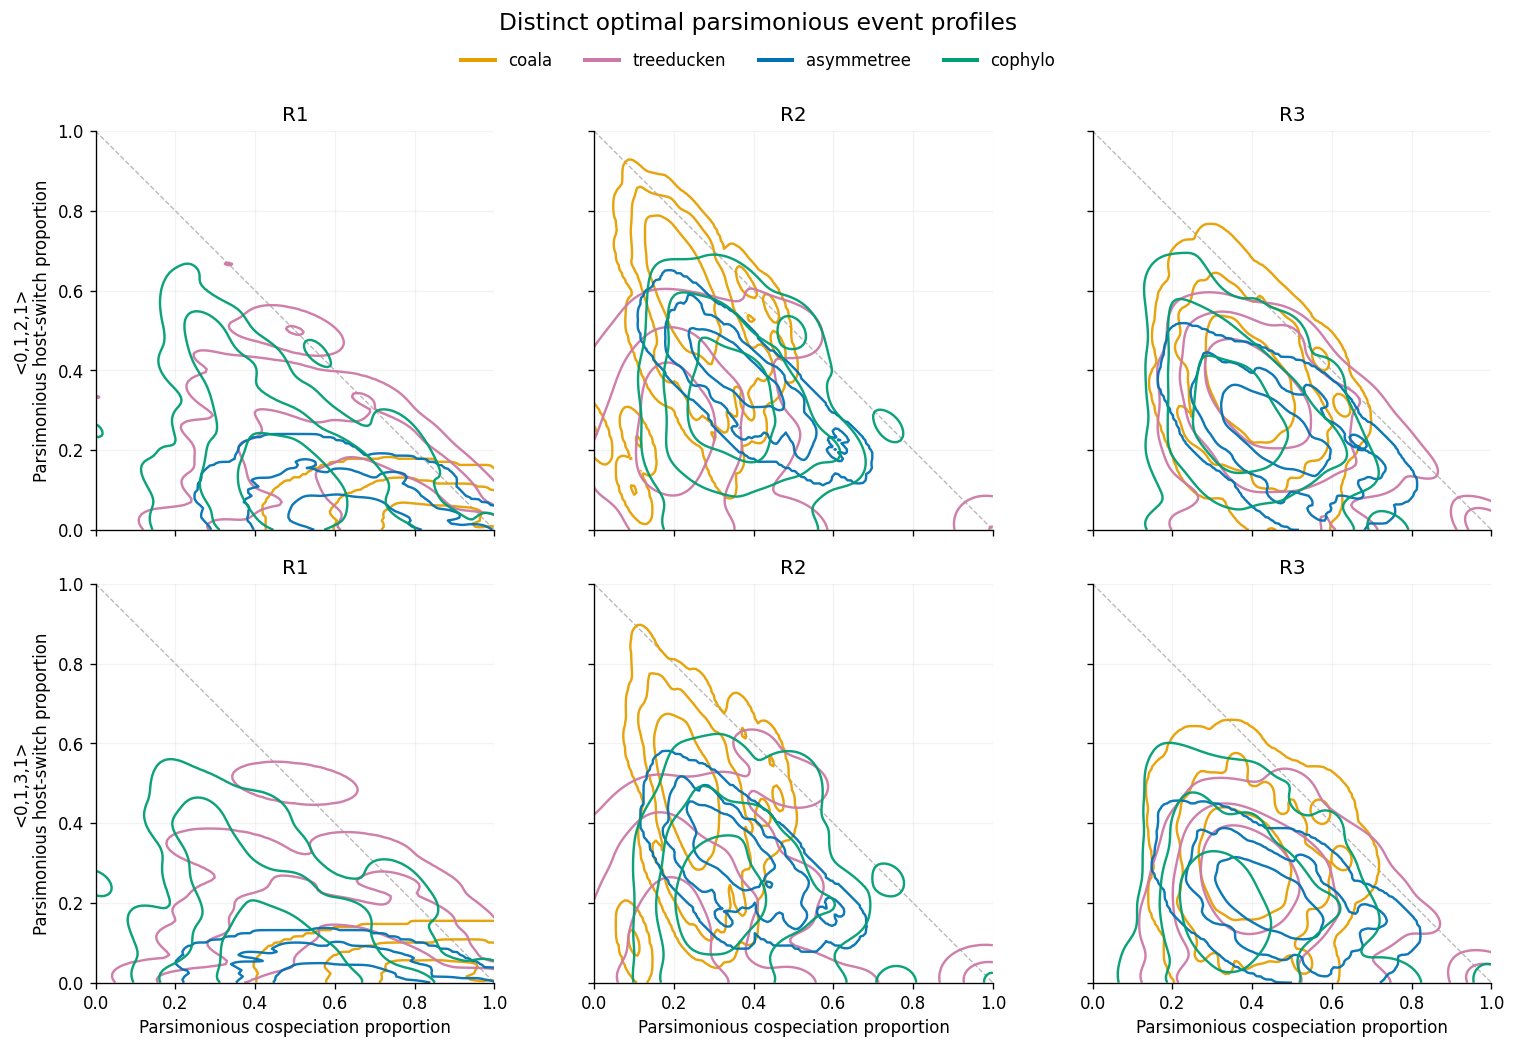

In [13]:
grid = np.linspace(0, 1, 130)
xx, yy = np.meshgrid(grid, grid)
positions = np.vstack([xx.ravel(), yy.ravel()])
fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.4), sharex=True, sharey=True)
for row_index, cost in enumerate(COSTS):
    for col_index, region in enumerate(REGIONS):
        ax = axes[row_index, col_index]
        panel = long_df[(long_df["region"] == region) & (long_df["cost_label"] == cost)]
        for generator in GENERATORS:
            group = panel[panel["generator"] == generator]
            if len(group) < 3:
                warnings.warn(f"Too few profiles for KDE: {region}, {cost}, {generator}")
                continue
            values = group[["c_opt", "s_opt"]].to_numpy().T
            try:
                kde = gaussian_kde(values, weights=group["dataset_weight"].to_numpy())
                density = kde(positions).reshape(xx.shape)
                positive = density[density > 0]
                levels = np.unique(np.quantile(positive, [0.70, 0.85, 0.95]))
                if len(levels): ax.contour(xx, yy, density, levels=levels, colors=[GENERATOR_COLORS[generator]], linewidths=1.45, alpha=0.95)
            except np.linalg.LinAlgError:
                warnings.warn(f"Singular KDE for {region}, {cost}, {generator}; drawing profile points instead.")
                ax.scatter(group["c_opt"], group["s_opt"], s=4, alpha=.15, color=GENERATOR_COLORS[generator])
        style_profile_axis(ax, region)
        if col_index == 0: ax.set_ylabel(f"{COST_NAMES[cost]}\nParsimonious host-switch proportion")
        if row_index == 1: ax.set_xlabel("Parsimonious cospeciation proportion")
fig.legend(handles=legend_handles, loc="upper center", ncol=len(GENERATORS), frameon=False, bbox_to_anchor=(.5, 1.01))
fig.suptitle("Distinct optimal parsimonious event profiles", y=1.035, fontsize=14)
fig.tight_layout()
figure1_files = save_figure(fig, "figure1_optimal_profile_density")
plt.show()

## Figure 2 — Mean optimal event profile per dataset

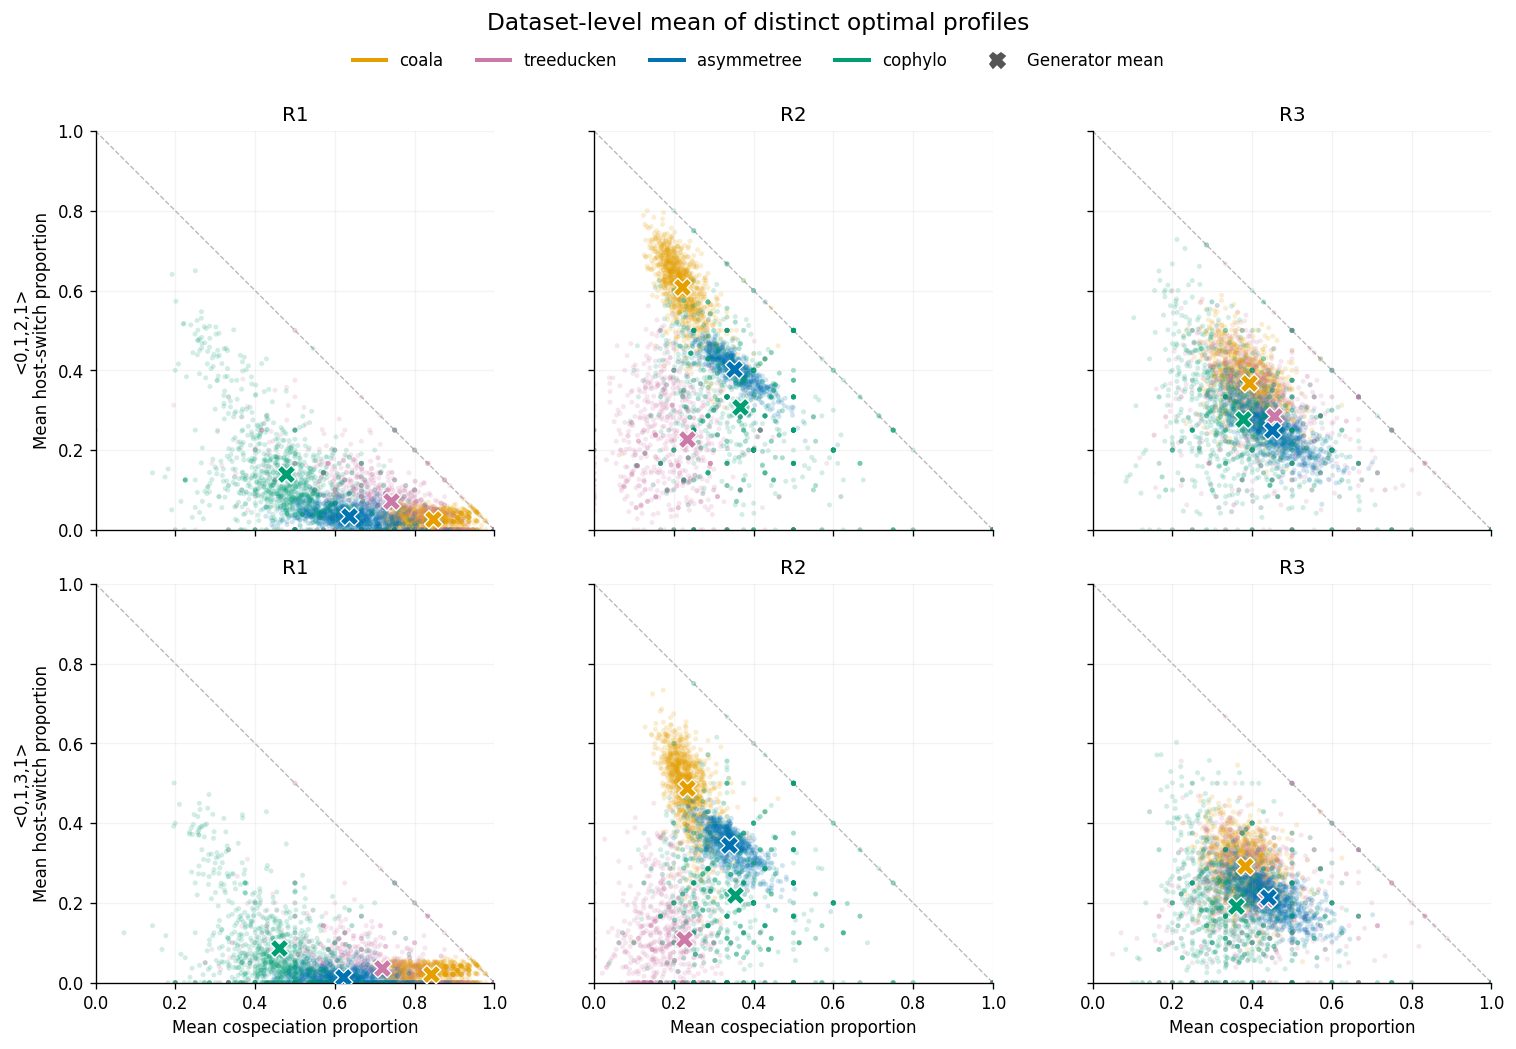

In [ ]:
dataset_means = long_df.groupby(["dataset_path", "generator", "regime", "region", "cost_label"], as_index=False).agg(mean_c_opt=("c_opt", "mean"), mean_s_opt=("s_opt", "mean"), event_vector_count=("event_vector_count", "first"))
fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.4), sharex=True, sharey=True)
for row_index, cost in enumerate(COSTS):
    for col_index, region in enumerate(REGIONS):
        ax = axes[row_index, col_index]
        panel = dataset_means[(dataset_means["region"] == region) & (dataset_means["cost_label"] == cost)]
        for generator in GENERATORS:
            group = panel[panel["generator"] == generator]
            ax.scatter(group["mean_c_opt"], group["mean_s_opt"], s=9, alpha=.18, color=GENERATOR_COLORS[generator], edgecolors="none")
            if not group.empty:
                ax.scatter(group["mean_c_opt"].mean(), group["mean_s_opt"].mean(), s=125, marker="X", color=GENERATOR_COLORS[generator], edgecolor="white", linewidth=.8, zorder=5)
        style_profile_axis(ax, region)
        if col_index == 0: ax.set_ylabel(f"{COST_NAMES[cost]}\nMean host-switch proportion")
        if row_index == 1: ax.set_xlabel("Mean cospeciation proportion")
mean_handle = Line2D([0], [0], marker="X", color="#555555", lw=0, markersize=9, label="Generator mean")
fig.legend(handles=legend_handles + [mean_handle], loc="upper center", ncol=len(GENERATORS) + 1, frameon=False, bbox_to_anchor=(.5, 1.01))
fig.suptitle("Mean optimal event profile per dataset", y=1.035, fontsize=14)
fig.tight_layout()
figure2_files = save_figure(fig, "figure2_mean_optimal_profiles")
plt.show()

## Figure 3 — ambiguity of optimal event composition

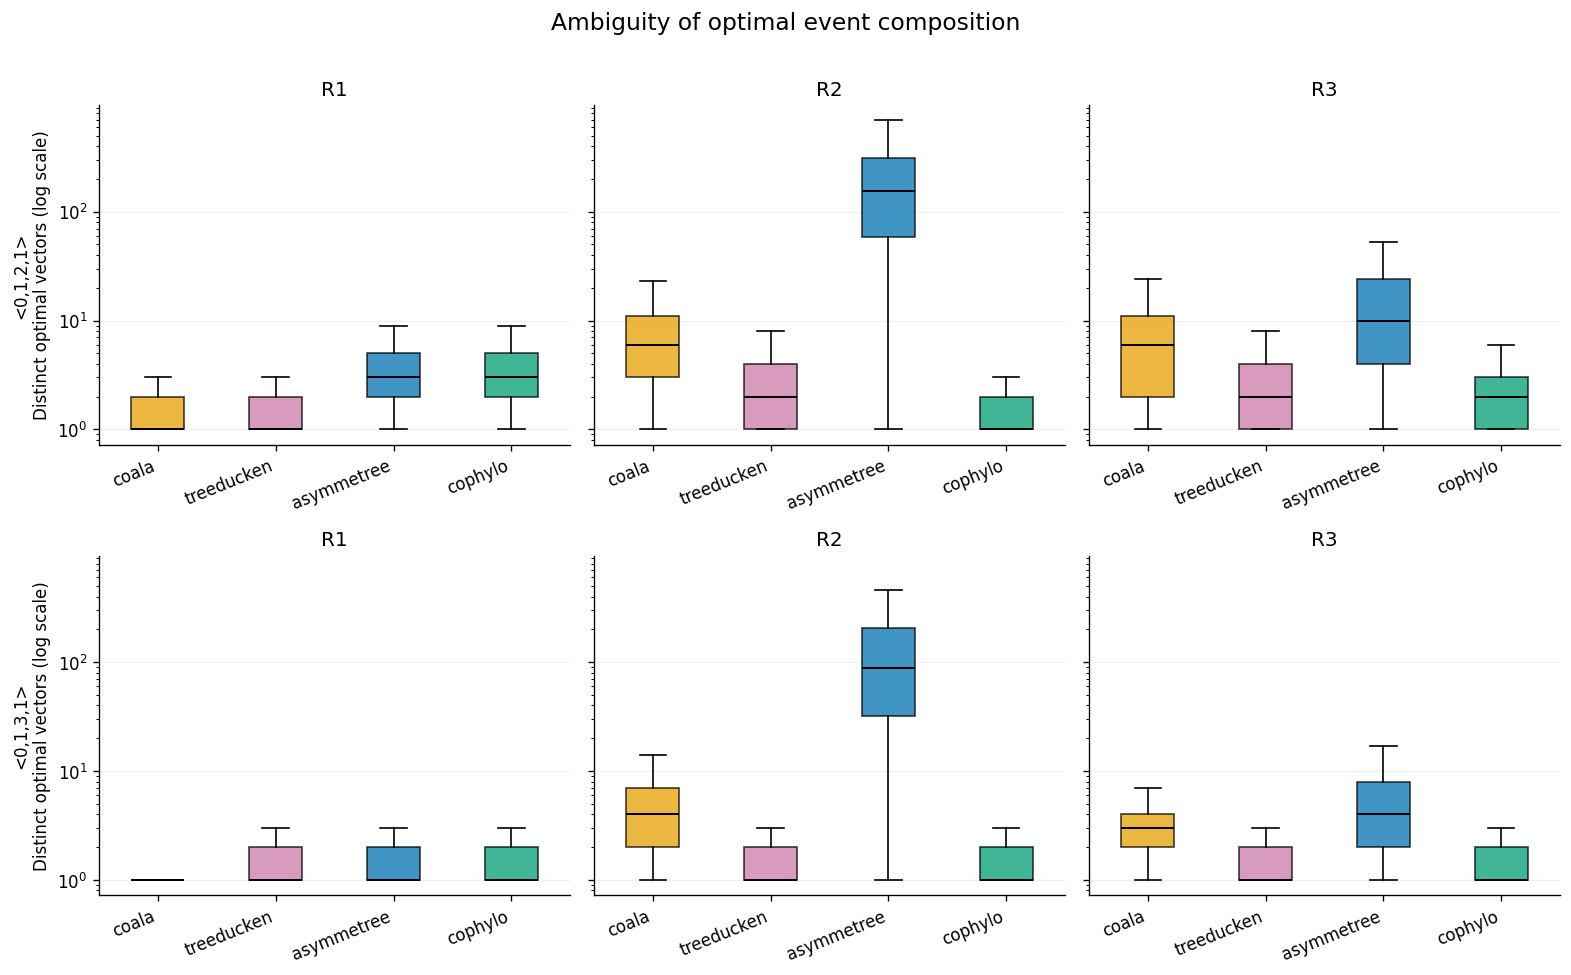

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.0), sharey=True)
for row_index, cost in enumerate(COSTS):
    for col_index, region in enumerate(REGIONS):
        ax = axes[row_index, col_index]
        panel = completed[(completed["region"] == region) & (completed["cost_label"] == cost)]
        arrays, labels, colors = [], [], []
        for generator in GENERATORS:
            values = panel.loc[panel["generator"] == generator, "event_vector_count"].dropna().to_numpy()
            if len(values): arrays.append(values); labels.append(generator); colors.append(GENERATOR_COLORS[generator])
        boxes = ax.boxplot(arrays, patch_artist=True, showfliers=False, medianprops={"color": "black", "lw": 1.2})
        for patch, color in zip(boxes["boxes"], colors): patch.set_facecolor(color); patch.set_alpha(.75)
        ax.set_yscale("log")
        ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels, rotation=22, ha="right")
        ax.set_title(region); ax.grid(axis="y", alpha=.18)
        if col_index == 0: ax.set_ylabel(f"{COST_NAMES[cost]}\nDistinct optimal vectors (log scale)")
fig.suptitle("Ambiguity of optimal event composition", y=1.01, fontsize=14)
fig.tight_layout()
figure3_files = save_figure(fig, "figure3_optimal_profile_ambiguity")
plt.show()

## Figure 4 — ambiguity of distinct optimal event profiles

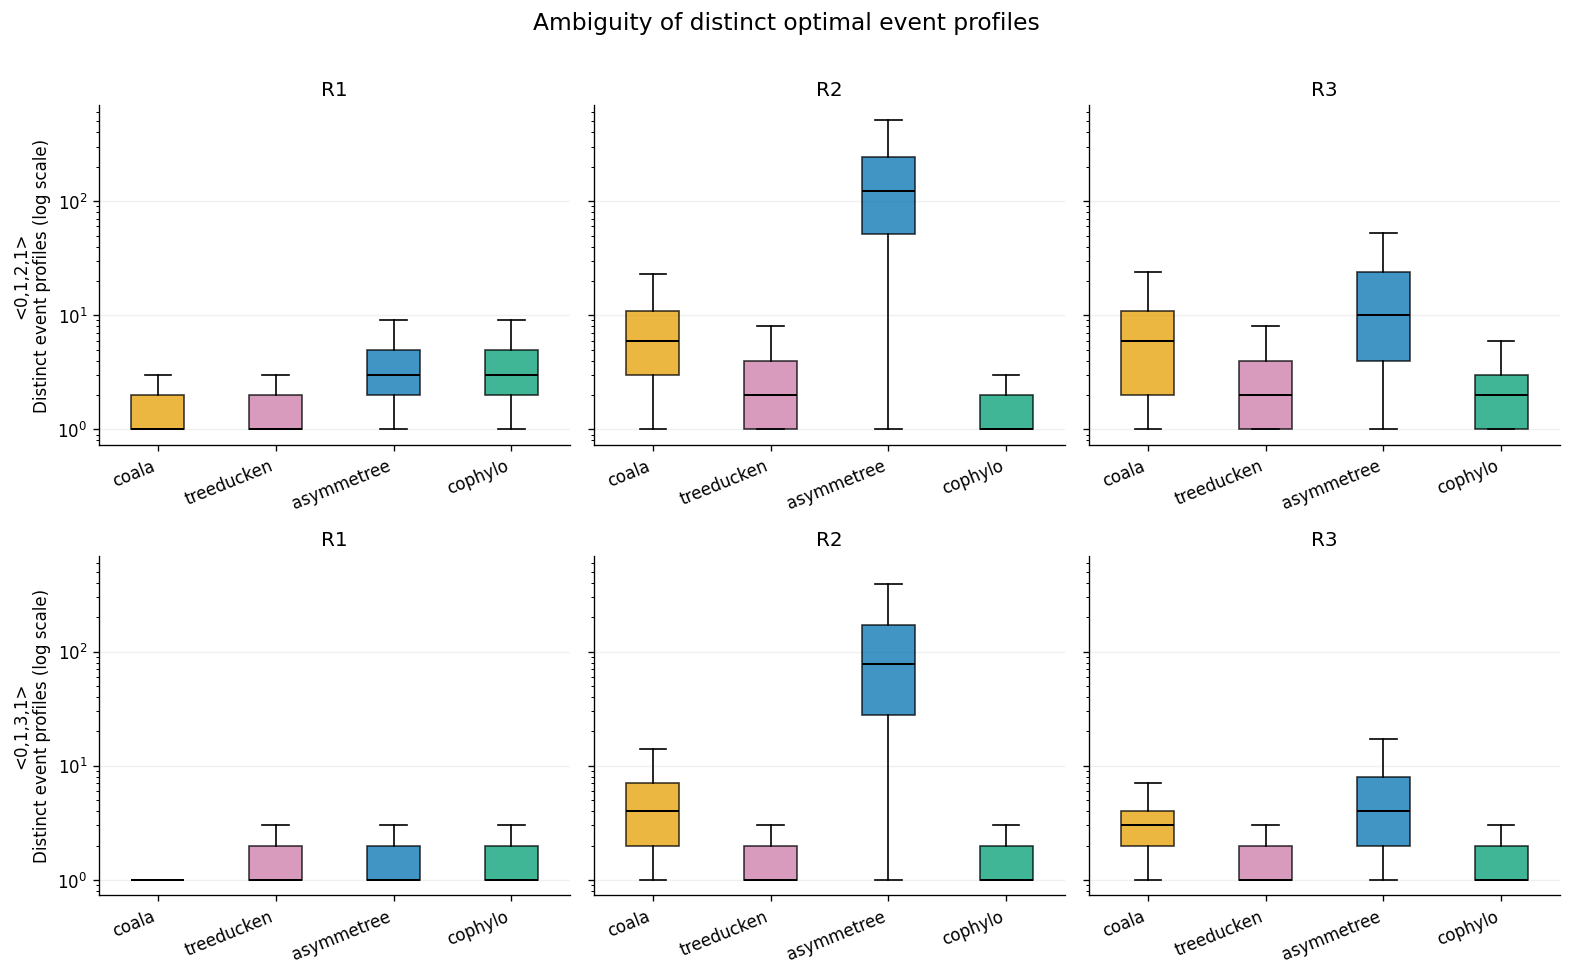

In [16]:
profile_counts = (
    long_df.assign(
        profile_key=long_df[["c_opt", "s_opt"]].apply(
            lambda row: (round(float(row["c_opt"]), 12), round(float(row["s_opt"]), 12)),
            axis=1,
        )
    )
    .groupby(["dataset_path", "generator", "regime", "region", "cost_label"], as_index=False)
    .agg(distinct_event_profiles=("profile_key", "nunique"))
)

fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.0), sharey=True)
for row_index, cost in enumerate(COSTS):
    for col_index, region in enumerate(REGIONS):
        ax = axes[row_index, col_index]
        panel = profile_counts[(profile_counts["region"] == region) & (profile_counts["cost_label"] == cost)]
        arrays, labels, colors = [], [], []
        for generator in GENERATORS:
            values = panel.loc[panel["generator"] == generator, "distinct_event_profiles"].dropna().to_numpy()
            if len(values):
                arrays.append(values)
                labels.append(generator)
                colors.append(GENERATOR_COLORS[generator])
        if arrays:
            boxes = ax.boxplot(arrays, patch_artist=True, showfliers=False, medianprops={"color": "black", "lw": 1.2})
            for patch, color in zip(boxes["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(.75)
        ax.set_yscale("log")
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=22, ha="right")
        ax.set_title(region)
        ax.grid(axis="y", alpha=.18)
        if col_index == 0:
            ax.set_ylabel(f"{COST_NAMES[cost]}\nDistinct event profiles (log scale)")

fig.suptitle("Ambiguity of distinct optimal event profiles", y=1.01, fontsize=14)
fig.tight_layout()
figure4_files = save_figure(fig, "figure4_distinct_event_profiles_ambiguity")
plt.show()

## Summary tables

In [18]:
sample_sizes = sample_sizes_completed.rename(columns={"completed_datasets": "completed_datasets_in_workbook"}).merge(
    dataset_means.groupby(["region", "generator", "cost_label"], as_index=False).agg(datasets_used_for_profiles=("dataset_path", "nunique")),
    on=["region", "generator", "cost_label"], how="left"
)
sample_sizes["datasets_excluded_by_parsing"] = sample_sizes["completed_datasets_in_workbook"] - sample_sizes["datasets_used_for_profiles"]
sample_sizes = sample_sizes.sort_values(["region", "cost_label", "generator"])

def q25(series): return series.quantile(.25)
def q75(series): return series.quantile(.75)

mean_profiles = dataset_means.groupby(["region", "generator", "cost_label"], as_index=False).agg(
    n=("dataset_path", "nunique"),
    mean_mean_c_opt=("mean_c_opt", "mean"), median_mean_c_opt=("mean_c_opt", "median"), q25_mean_c_opt=("mean_c_opt", q25), q75_mean_c_opt=("mean_c_opt", q75),
    mean_mean_s_opt=("mean_s_opt", "mean"), median_mean_s_opt=("mean_s_opt", "median"), q25_mean_s_opt=("mean_s_opt", q25), q75_mean_s_opt=("mean_s_opt", q75),
).sort_values(["region", "cost_label", "generator"])

profile_counts = (
    long_df.assign(
        profile_key=long_df[["c_opt", "s_opt"]].apply(
            lambda row: (round(float(row["c_opt"]), 12), round(float(row["s_opt"]), 12)),
            axis=1,
        )
    )
    .groupby(["dataset_path", "generator", "regime", "region", "cost_label"], as_index=False)
    .agg(distinct_event_profiles=("profile_key", "nunique"))
    .groupby(["region", "generator", "cost_label"], as_index=False)
    .agg(
        n=("dataset_path", "nunique"),
        median_distinct_event_profiles=("distinct_event_profiles", "median"),
        q25_distinct_event_profiles=("distinct_event_profiles", q25),
        q75_distinct_event_profiles=("distinct_event_profiles", q75),
    )
    .sort_values(["region", "cost_label", "generator"])
)

def parse_big_int(value):
    text = str(value).strip()
    if not text or text.lower() == "nan": return None
    return int(Decimal(text))

def exact_quantile(values, q):
    values = sorted(v for v in values if v is not None)
    if not values: return None
    position = Decimal(str(q)) * Decimal(len(values) - 1)
    lower = int(position)
    upper = min(lower + 1, len(values) - 1)
    fraction = position - lower
    with localcontext() as context:
        context.prec = max(50, len(str(values[-1])) + 10)
        return Decimal(values[lower]) + fraction * Decimal(values[upper] - values[lower])

ambiguity_rows = []
for (region, generator, cost), group in completed.groupby(["region", "generator", "cost_label"]):
    ev = group["event_vector_count"].tolist()
    opt = [parse_big_int(value) for value in group["optimal_count"]]
    ambiguity_rows.append({
        "region": region,
        "generator": generator,
        "cost_label": cost,
        "n": group["dataset_path"].nunique(),
        "median_event_vector_count": exact_quantile(ev, .5),
        "q25_event_vector_count": exact_quantile(ev, .25),
        "q75_event_vector_count": exact_quantile(ev, .75),
        "median_optimal_count": exact_quantile(opt, .5),
        "q25_optimal_count": exact_quantile(opt, .25),
        "q75_optimal_count": exact_quantile(opt, .75),
    })
ambiguity = pd.DataFrame(ambiguity_rows).sort_values(["region", "cost_label", "generator"])

for table in [sample_sizes, mean_profiles, profile_counts, ambiguity]:
    table["cost_vector"] = table["cost_label"].map(COST_NAMES)

def decimal_scientific(value):
    if value is None or pd.isna(value):
        return ""
    value = Decimal(value)
    return f"{value:.3E}" if abs(value) >= Decimal("1e6") else f"{value:f}"

outputs = []
for table, stem in [
    (sample_sizes, "downstream_sample_sizes"),
    (mean_profiles, "downstream_mean_profiles"),
    (profile_counts, "downstream_profile_counts"),
    (ambiguity, "downstream_ambiguity"),
]:
    csv_path = TABLE_DIR / f"{stem}.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"
    table.to_csv(csv_path, index=False)
    latex_table = table.copy()
    if stem == "downstream_ambiguity":
        for column in ["median_optimal_count", "q25_optimal_count", "q75_optimal_count"]:
            latex_table[column] = latex_table[column].map(decimal_scientific)
    tex_path.write_text(
        latex_table.to_latex(index=False, float_format=lambda value: f"{value:.4f}"),
        encoding="utf-8",
    )
    outputs.extend([csv_path, tex_path])

display(sample_sizes)
display(mean_profiles)
display(profile_counts)
display(ambiguity)

,region,generator,cost_label,completed_datasets_in_workbook,cost_vector,datasets_used_for_profiles,datasets_excluded_by_parsing
0,R1,asymmetree,classical_1,1000,"<0,1,2,1>",1000,0
2,R1,coala,classical_1,1000,"<0,1,2,1>",1000,0
4,R1,cophylo,classical_1,989,"<0,1,2,1>",989,0
6,R1,treeducken,classical_1,989,"<0,1,2,1>",989,0
1,R1,asymmetree,classical_3,1000,"<0,1,3,1>",1000,0
3,R1,coala,classical_3,1000,"<0,1,3,1>",1000,0
5,R1,cophylo,classical_3,989,"<0,1,3,1>",989,0
7,R1,treeducken,classical_3,990,"<0,1,3,1>",990,0
8,R2,asymmetree,classical_1,798,"<0,1,2,1>",697,101
10,R2,coala,classical_1,1000,"<0,1,2,1>",1000,0


,region,generator,cost_label,n,mean_mean_c_opt,median_mean_c_opt,q25_mean_c_opt,q75_mean_c_opt,mean_mean_s_opt,median_mean_s_opt,q25_mean_s_opt,q75_mean_s_opt,cost_vector
0,R1,asymmetree,classical_1,1000,0.634483,0.633460,0.580295,0.686289,0.035512,0.033604,0.018155,0.049392,"<0,1,2,1>"
2,R1,coala,classical_1,1000,0.845836,0.842661,0.791667,0.895833,0.026332,0.026484,0.010204,0.041667,"<0,1,2,1>"
4,R1,cophylo,classical_1,989,0.477948,0.478145,0.404654,0.543165,0.138877,0.112129,0.066667,0.176633,"<0,1,2,1>"
6,R1,treeducken,classical_1,989,0.740794,0.736374,0.636508,0.851420,0.071582,0.062500,0.000000,0.111111,"<0,1,2,1>"
1,R1,asymmetree,classical_3,1000,0.621007,0.620248,0.565232,0.674278,0.014693,0.011628,0.000000,0.023810,"<0,1,3,1>"
3,R1,coala,classical_3,1000,0.841688,0.837083,0.787234,0.894737,0.021607,0.020833,0.000000,0.040000,"<0,1,3,1>"
5,R1,cophylo,classical_3,989,0.459253,0.454545,0.386827,0.517246,0.086209,0.055556,0.016129,0.120000,"<0,1,3,1>"
7,R1,treeducken,classical_3,990,0.717098,0.704692,0.600000,0.826313,0.037176,0.000000,0.000000,0.058531,"<0,1,3,1>"
8,R2,asymmetree,classical_1,697,0.350803,0.346775,0.314710,0.381362,0.403256,0.408042,0.375053,0.431929,"<0,1,2,1>"
10,R2,coala,classical_1,1000,0.219859,0.214683,0.190441,0.243440,0.608195,0.619938,0.561558,0.661903,"<0,1,2,1>"


,region,generator,cost_label,n,median_distinct_event_profiles,q25_distinct_event_profiles,q75_distinct_event_profiles,cost_vector
0,R1,asymmetree,classical_1,1000,3.0,2.0,5.0,"<0,1,2,1>"
2,R1,coala,classical_1,1000,1.0,1.0,2.0,"<0,1,2,1>"
4,R1,cophylo,classical_1,989,3.0,2.0,5.0,"<0,1,2,1>"
6,R1,treeducken,classical_1,989,1.0,1.0,2.0,"<0,1,2,1>"
1,R1,asymmetree,classical_3,1000,1.0,1.0,2.0,"<0,1,3,1>"
3,R1,coala,classical_3,1000,1.0,1.0,1.0,"<0,1,3,1>"
5,R1,cophylo,classical_3,989,1.0,1.0,2.0,"<0,1,3,1>"
7,R1,treeducken,classical_3,990,1.0,1.0,2.0,"<0,1,3,1>"
8,R2,asymmetree,classical_1,697,124.0,52.0,244.0,"<0,1,2,1>"
10,R2,coala,classical_1,1000,6.0,3.0,11.0,"<0,1,2,1>"


,region,generator,cost_label,n,median_event_vector_count,q25_event_vector_count,q75_event_vector_count,median_optimal_count,q25_optimal_count,q75_optimal_count,cost_vector
0,R1,asymmetree,classical_1,1000,3.0,2.00,5.00,4.0,2.00,16.00,"<0,1,2,1>"
2,R1,coala,classical_1,1000,1.0,1.00,2.00,1.0,1.00,2.00,"<0,1,2,1>"
4,R1,cophylo,classical_1,989,3.0,2.00,5.00,6.0,2.00,40.00,"<0,1,2,1>"
6,R1,treeducken,classical_1,989,1.0,1.00,2.00,2.0,1.00,4.00,"<0,1,2,1>"
1,R1,asymmetree,classical_3,1000,1.0,1.00,2.00,1.0,1.00,2.00,"<0,1,3,1>"
3,R1,coala,classical_3,1000,1.0,1.00,1.00,1.0,1.00,1.00,"<0,1,3,1>"
5,R1,cophylo,classical_3,989,1.0,1.00,2.00,2.0,1.00,8.00,"<0,1,3,1>"
7,R1,treeducken,classical_3,990,1.0,1.00,2.00,1.0,1.00,2.00,"<0,1,3,1>"
8,R2,asymmetree,classical_1,798,153.5,59.00,311.75,102865237548835980737249280.0,467980441878528.00,700427606085411250000000000000000000000.00,"<0,1,2,1>"
10,R2,coala,classical_1,1000,6.0,3.00,11.00,221184.0,768.00,22415360.00,"<0,1,2,1>"


## Generated files

In [19]:
generated_files = figure1_files + figure2_files + figure3_files + figure4_files + outputs + [TABLE_DIR / "optimal_event_profiles_long.csv"]
if not parsing_failures.empty: generated_files.append(TABLE_DIR / "event_vector_parsing_failures.csv")
print("Generated files:")
for path in generated_files: print(" -", path)

Generated files:
 - downstream_figures/figure1_optimal_profile_density.pdf
 - downstream_figures/figure1_optimal_profile_density.png
 - downstream_figures/figure2_mean_optimal_profiles.pdf
 - downstream_figures/figure2_mean_optimal_profiles.png
 - downstream_figures/figure3_optimal_profile_ambiguity.pdf
 - downstream_figures/figure3_optimal_profile_ambiguity.png
 - downstream_figures/figure4_distinct_event_profiles_ambiguity.pdf
 - downstream_figures/figure4_distinct_event_profiles_ambiguity.png
 - downstream_tables/downstream_sample_sizes.csv
 - downstream_tables/downstream_sample_sizes.tex
 - downstream_tables/downstream_mean_profiles.csv
 - downstream_tables/downstream_mean_profiles.tex
 - downstream_tables/downstream_profile_counts.csv
 - downstream_tables/downstream_profile_counts.tex
 - downstream_tables/downstream_ambiguity.csv
 - downstream_tables/downstream_ambiguity.tex
 - downstream_tables/optimal_event_profiles_long.csv
 - downstream_tables/event_vector_parsing_failures.csv